# 第057讲 最近邻与局部预测
先完成讲义手算，再执行本Notebook。每次执行真实重跑六条分类、两条回归、四十份重复训练与固定维度对照。所有数据原创且离线可用。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image
from knn import KNN
import experiment as e
from plots import make_figures
from test_experiment import audit
ROOT = Path.cwd()
print(json.loads((ROOT / "data/protocol.json").read_text()))

{'classification_split': [360, 180, 360], 'regression_split': [100, 80, 200], 'ks': [1, 5, 21, 61], 'tie_break': 'smaller k', 'reference': 'sklearn brute force; random draws have no distance ties', 'all_routes_fixed_before_test': True, 'classification_routes': ['raw', 'scaled', 'scaled_noise20'], 'weights': ['uniform', 'distance'], 'scaler_fit_rows': [0, 360], 'dimension_ablation_fixed_k': 21, 'dimension_ablation_noise_dimensions': [0, 2, 5, 10, 20], 'bias_variance_repetitions': 40, 'bias_variance_training_rows': 80, 'bias_variance_target': 'true conditional mean', 'vote_tie': 'predict 0', 'distance_tie': 'stable training row order', 'test_used_for_selection': False}


## 手算必须先通过
查询1到训练0、2、5的距离为1、1、4；等权k=2答案2；逆距离k=3答案26/9。零距离重复标签0和1的概率为0.5，按规则预测0。

In [2]:
X = np.array([[0.], [2.], [5.]])
print(KNN(2, task="regression").fit(X, [0,4,10]).predict([[1.]]))
print(KNN(3, "distance", "regression").fit(X, [0,4,10]).predict([[1.]]))
print(KNN(3, "distance").fit([[0.],[0.],[2.]], [0,1,1]).predict_proba([[0.]]))

[2.]
[2.88888889]
[[0.5 0.5]]


## 重跑完整协议
只由验证集选择k；路线和权重已预先固定并全部报告。保存所有测试概率与重复训练预测，便于独立审计。

In [3]:
result = e.run()
display(pd.DataFrame([{k:v for k,v in row.items() if k in ["route","weights","selected_k","test_error","library_max_error"]} for row in result["classification"]]))

,route,weights,selected_k,test_error,library_max_error
0,raw,uniform,21,0.180556,3.330669e-16
1,raw,distance,61,0.183333,3.813817e-12
2,scaled,uniform,5,0.108333,1.110223e-16
3,scaled,distance,5,0.111111,6.394885e-14
4,scaled_noise20,uniform,61,0.205556,2.220446e-16
5,scaled_noise20,distance,61,0.202778,3.330669e-16


In [4]:
display(pd.DataFrame([{k:v for k,v in row.items() if k in ["weights","selected_k","test_mse","library_max_error"]} for row in result["regression"]]))
print(audit(result))

,weights,selected_k,test_mse,library_max_error
0,uniform,5,0.111203,2.220446e-16
1,distance,21,0.126908,1.284206e-11


{'status': 'passed', 'independently_reconstructed_validation_candidates': 24, 'training_only_scalers': 2, 'hand_cases': 4, 'random_library_comparisons': 12, 'common_invalid_inputs': 9, 'report_routes': 8, 'bias_variance_identities': 4, 'library_tolerance': 1e-09}


## 从预测矩阵独立重算分解
方差沿重复训练集的轴计算，ddof=0。本图不加新标签噪声0.09。

In [5]:
truth = np.sin(2*np.array(result["bias_variance_grid"]))
rows = []
for row in result["bias_variance"]:
    p = np.array(row["predictions"])
    b = np.mean((p.mean(0)-truth)**2)
    v = np.mean(p.var(0, ddof=0))
    error = np.mean((p-truth)**2)
    rows.append({"k": row["k"], "bias2": b, "variance": v, "error": error, "identity_residual": error-b-v})
display(pd.DataFrame(rows))

,k,bias2,variance,error,identity_residual
0,1,0.002453,0.090841,0.093293,1.387779e-17
1,5,0.002064,0.024525,0.026589,3.469447e-18
2,21,0.093518,0.030750,0.124268,2.775558e-17
3,61,0.598287,0.013317,0.611604,-7.979728e-17


## 从这次运行重建六张图
图3显示坐标恢复为x1/40，但计算距离仍按各路线；图6右侧只描述一个固定测试查询。

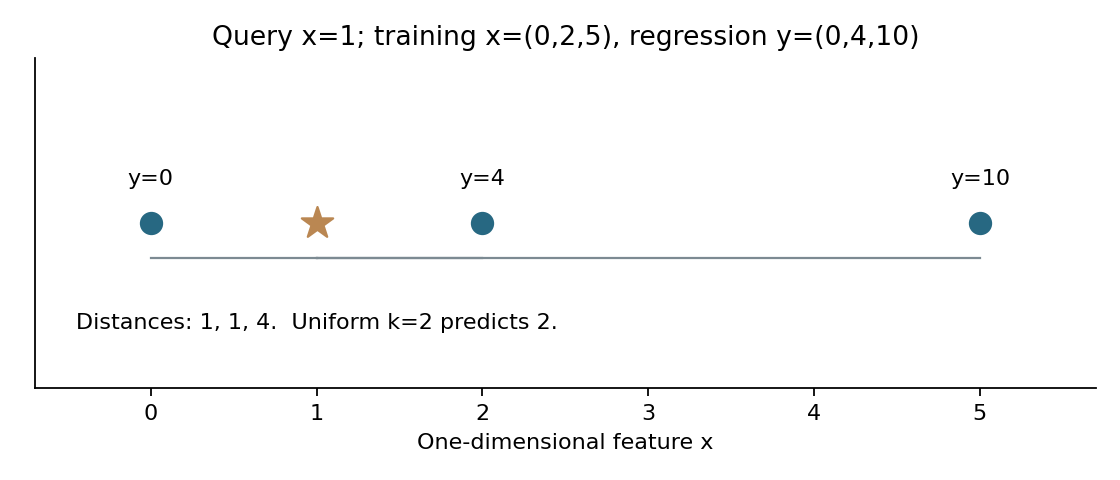

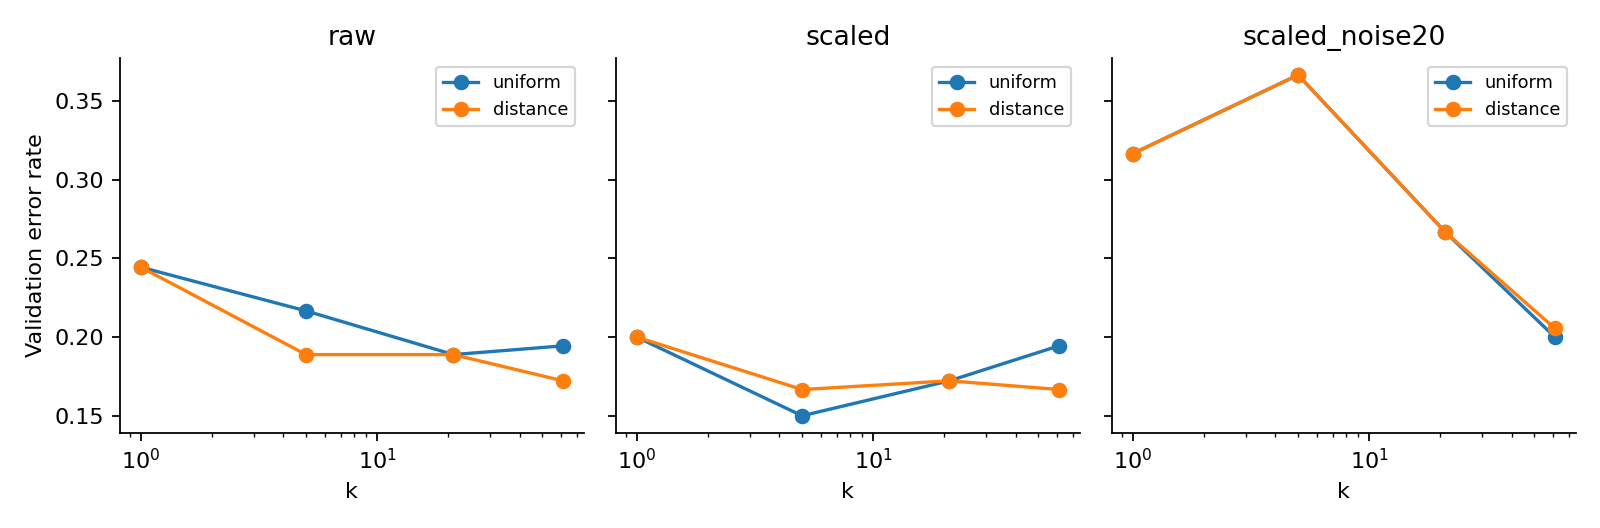

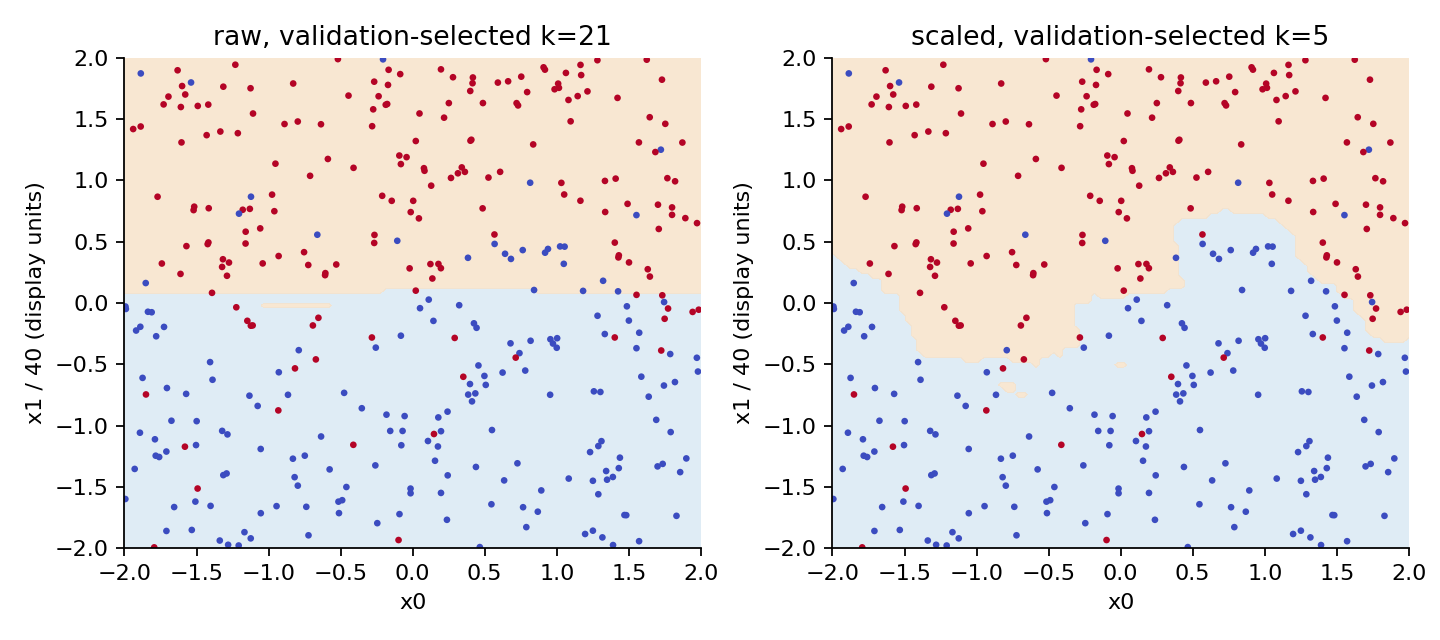

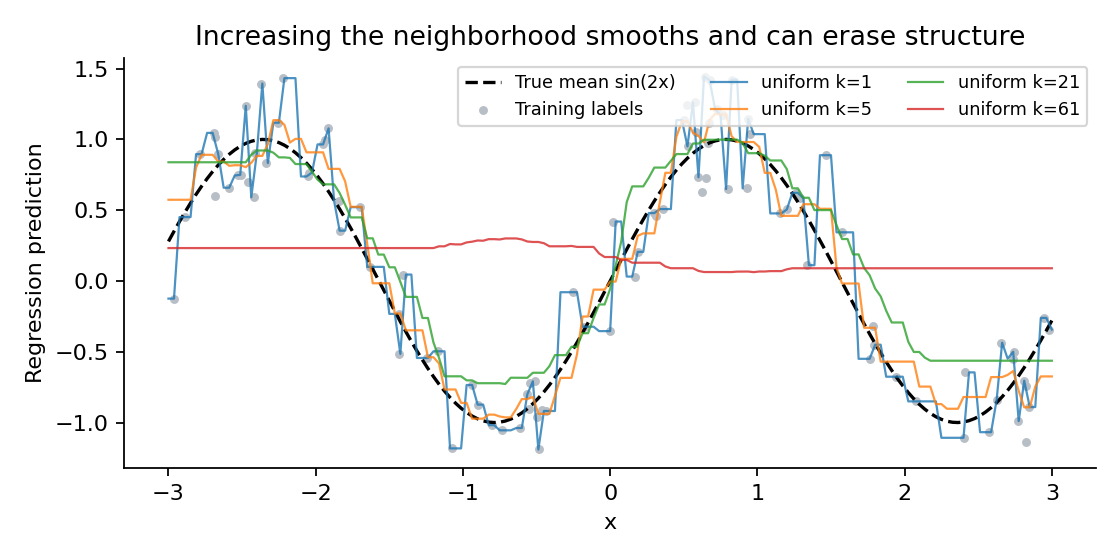

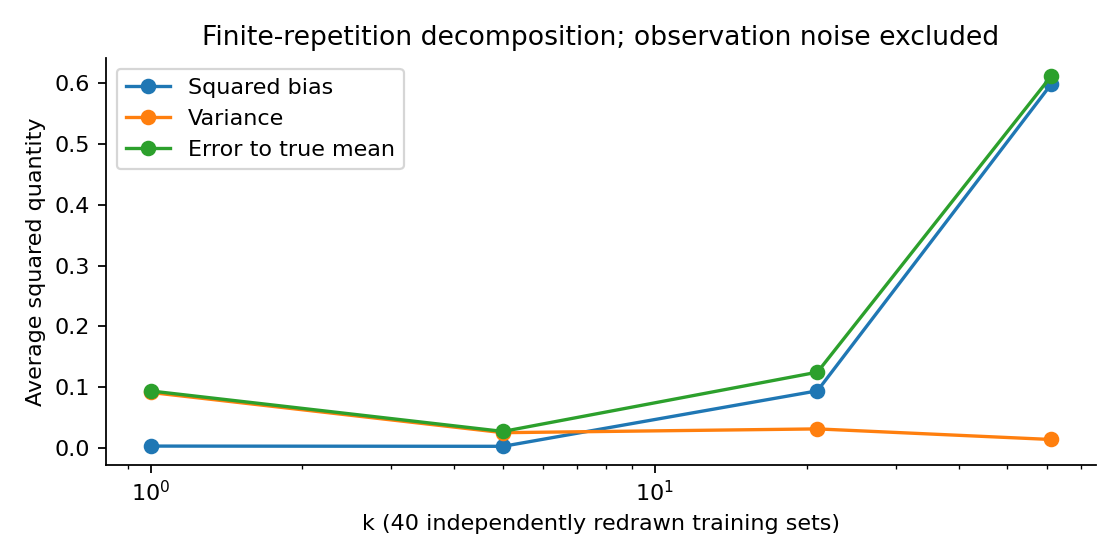

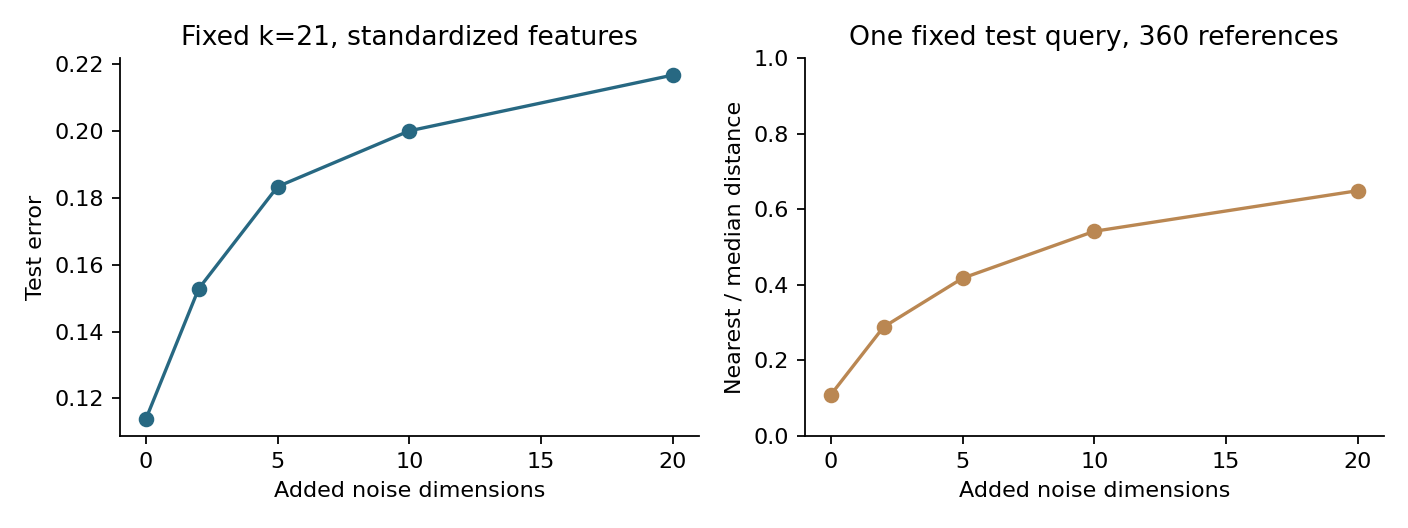

In [6]:
paths = make_figures(result, ROOT / "outputs/notebook-figures")
for path in paths:
    display(Image(filename=str(path)))

In [7]:
display(pd.DataFrame(result["dimensions"]))
print("Reject k=True:")
try:
    KNN(True)
except ValueError as error:
    print(type(error).__name__, str(error))

,noise_dimensions,test_error,nearest,median,nearest_over_median
0,0,0.113889,0.152175,1.389767,0.109497
1,2,0.152778,0.600741,2.082694,0.288444
2,5,0.183333,1.224587,2.932689,0.417565
3,10,0.200000,2.179243,4.023799,0.541588
4,20,0.216667,3.703490,5.707496,0.648882


Reject k=True:
ValueError k must be a positive integer


## 写下边界
逆距离未全面胜出；方差不严格单调；测试排名可以不同于验证排名。请完成lab.md的A至G，再查看answers.md。修改参数属于探索，使用新输出目录并保留固定协议结果。